In [6]:
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

# load data
df = pd.read_csv('data.csv')

# clean data
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['make'].str.lower().str.replace(' ', '_')
df = df[df['msrp'] > 0]

strings = list(df.dtypes[df.dtypes == 'str'].index)
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

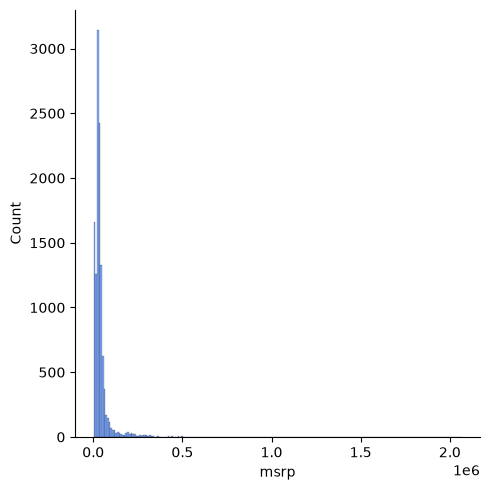

In [7]:
# visualize data
sns.displot(data=df, x='msrp')


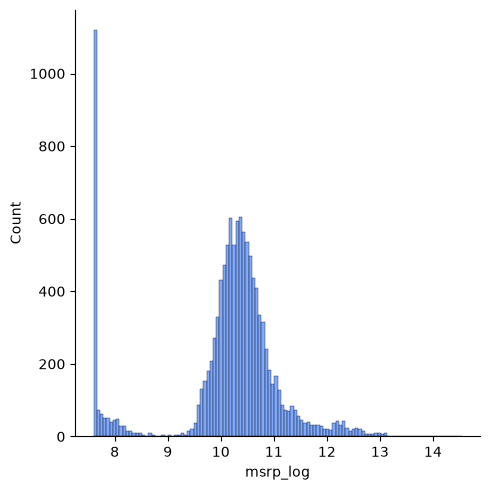

In [8]:
# long tail distribution log transformation
df['msrp_log'] = np.log1p(df.msrp)
sns.displot(data=df, x='msrp_log')

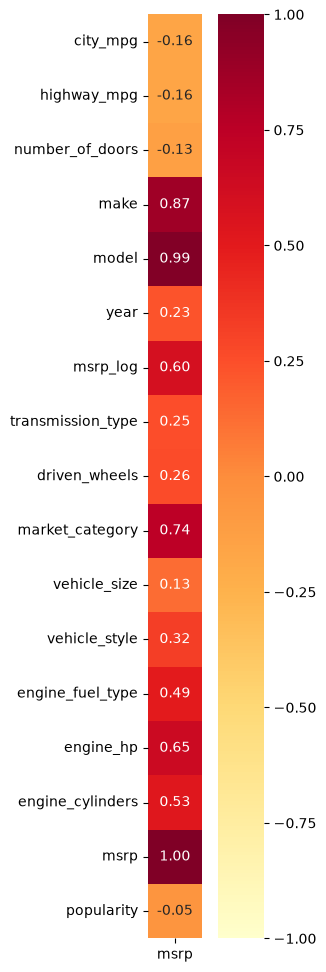

{'corr':                        msrp
 city_mpg          -0.157676
 highway_mpg       -0.160043
 number_of_doors   -0.128627
 make               0.869154
 model              0.986387
 year               0.227590
 msrp_log           0.596551
 transmission_type  0.253885
 driven_wheels      0.263483
 market_category    0.743560
 vehicle_size       0.126775
 vehicle_style      0.323254
 engine_fuel_type   0.493594
 engine_hp          0.650095
 engine_cylinders   0.526274
 msrp               1.000000
 popularity        -0.048476,
 'ax': <Axes: >}

In [9]:
from dython.nominal import associations
from matplotlib import colormaps

df_dython = df.copy()
for col in df_dython.select_dtypes(exclude=['number']).columns:
    df_dython[col] = df_dython[col].astype(object)

associations(df_dython, figsize=(4, 12), display_columns='msrp', clustering=True, cmap=colormaps.get('YlOrRd'))

In [10]:
# shuffle dataset (random_state aka seed for reproducibility)
df = df.sample(frac=1, random_state=2).reset_index(drop=True)
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,msrp_log
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410,9.575747
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685,9.887663
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795,9.893235
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000,7.601402
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260,10.937757


In [11]:
# split dataset into 3 parts for training, validation and testing
n = len(df)
val_size = int(0.2 * n)
test_size = int(0.2 * n)
train_size = n - val_size - test_size

x_train = df[:train_size]
x_val = df[train_size:train_size + val_size]
x_test = df[train_size + val_size:]

len(x_train), len(x_val), len(x_val)

(7150, 2382, 2382)

In [12]:
# extract features and targets

y_train = x_train.msrp_log
del x_train['msrp_log']
del x_train['msrp']

y_val = x_val.msrp_log
del x_val['msrp_log']
del x_val['msrp']

y_test = x_test.msrp_log
del x_test['msrp_log']
del x_test['msrp']

x_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


<Axes: xlabel='msrp_log', ylabel='Count'>

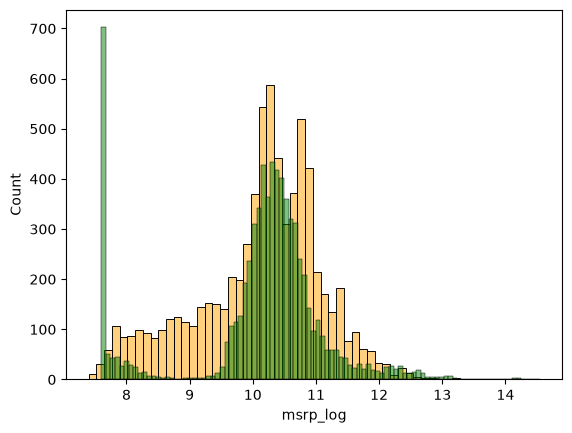

In [13]:
# Linear Regression: y = W * X + b
# Weights
features = ["engine_hp", "engine_cylinders", "year"]


def train(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    w = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)
    return w[0], w[1:]


def predict(b, W, x):
    return x.dot(W) + b


x_train_base = x_train[features].fillna(0)
b, W = train(x_train_base.values, y_train.values)
y_pred = predict(b, W, x_train_base.values)

sns.histplot(y_pred, label='predicted', color='orange', alpha=0.5)
sns.histplot(y_train, label='actual', color='green', alpha=0.5)


In [14]:
# RSME
rmse = np.sqrt(np.mean((y_pred - y_train) ** 2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.5260


<Axes: xlabel='msrp_log', ylabel='Count'>

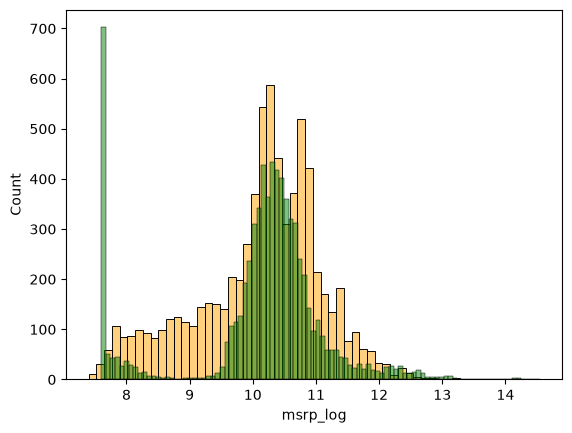

In [15]:
# add year feature
features.append("year")
x_train_v1 = x_train[features].fillna(0)
b, W = train(x_train_v1.values, y_train.values)
y_pred = predict(b, W, x_train_v1.values)
sns.histplot(y_pred, label='predicted', color='orange', alpha=0.5)
sns.histplot(y_train, label='actual', color='green', alpha=0.5)

In [16]:
rmse = np.sqrt(np.mean((y_pred - y_train) ** 2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.5260


<Axes: xlabel='msrp_log', ylabel='Count'>

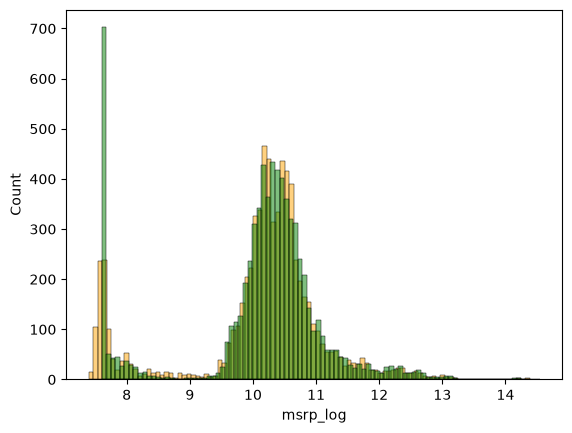

In [17]:
# add model feature

x_train = pd.get_dummies(x_train, columns=['model'], drop_first=True, dtype=int)
features = features + [col for col in x_train.columns if col.startswith('model_')]
x_train_v2 = x_train[features].fillna(0)
b, W = train(x_train_v2.values, y_train.values)
y_pred = predict(b, W, x_train_v2.values)
sns.histplot(y_pred, label='predicted', color='orange', alpha=0.5)
sns.histplot(y_train, label='actual', color='green', alpha=0.5)

In [18]:
rmse = np.sqrt(np.mean((y_pred - y_train) ** 2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.1811


<Axes: xlabel='msrp_log', ylabel='Count'>

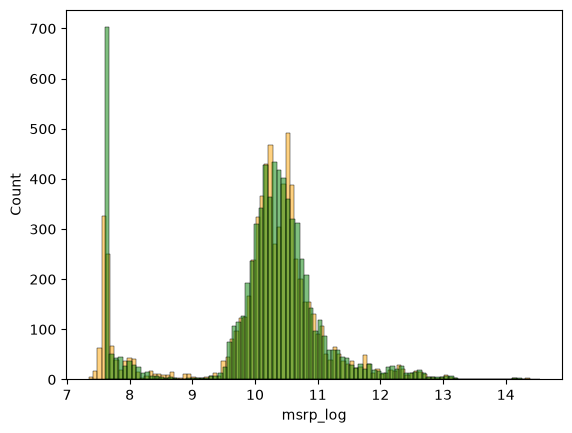

In [19]:
x_train = pd.get_dummies(x_train, columns=['make'], drop_first=True, dtype=int)
features = features + [col for col in x_train.columns if col.startswith('make_')]
x_train_v3 = x_train[features].fillna(0)
b, W = train(x_train_v3.values, y_train.values)
y_pred = predict(b, W, x_train_v3.values)
sns.histplot(y_pred, label='predicted', color='orange', alpha=0.5)
sns.histplot(y_train, label='actual', color='green', alpha=0.5)

In [20]:
rmse = np.sqrt(np.mean((y_pred - y_train) ** 2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.1617


In [21]:
# # add market_category feature
# x_train = pd.get_dummies(x_train, columns=['market_category'], drop_first=True, dtype=int)
# features = features + [col for col in x_train.columns if col.startswith('market_category_')]
# x_train_v4 = x_train[features].fillna(0)
# b, W = train(x_train_v4.values, y_train.values)
# y_pred = predict(b, W, x_train_v4.values)
# sns.histplot(y_pred, label='predicted', color='orange', alpha=0.5)
# sns.histplot(y_train, label='actual', color='green', alpha=0.5)

In [22]:
# rmse = np.sqrt(np.mean((y_pred - y_train) ** 2))
# print(f"RMSE: {rmse:.4f}")

<Axes: xlabel='msrp_log', ylabel='Count'>

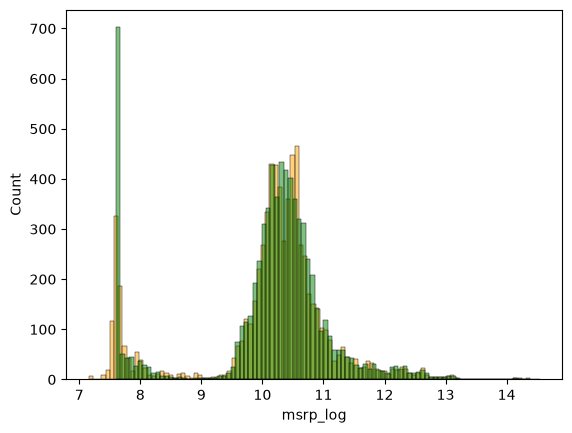

In [23]:
# add transmission_type feature
x_train = pd.get_dummies(x_train, columns=['transmission_type'], drop_first=True, dtype=int)
features = features + [col for col in x_train.columns if col.startswith('transmission_type_')]
x_train_v5 = x_train[features].fillna(0)
b, W = train(x_train_v5.values, y_train.values)
y_pred = predict(b, W, x_train_v5.values)
sns.histplot(y_pred, label='predicted', color='orange', alpha=0.5)
sns.histplot(y_train, label='actual', color='green', alpha=0.5)

In [24]:
rmse = np.sqrt(np.mean((y_pred - y_train) ** 2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.1594


In [25]:
# add driven_wheels feature
# x_train = pd.get_dummies(x_train, columns=['driven_wheels'], drop_first=True, dtype=int)
# features = features + [col for col in x_train.columns if col.startswith('driven_wheels_')]
# x_train_v6 = x_train[features].fillna(0)
# b, W = train(x_train_v6.values, y_train.values)
# y_pred = predict(b, W, x_train_v6.values)
# sns.histplot(y_pred, label='predicted', color='orange', alpha=0.5)
# sns.histplot(y_train, label='actual', color='green', alpha=0.5)

In [26]:
# rmse = np.sqrt(np.mean((y_pred - y_train) ** 2))
# print(f"RMSE: {rmse:.4f}")

<Axes: xlabel='msrp_log', ylabel='Count'>

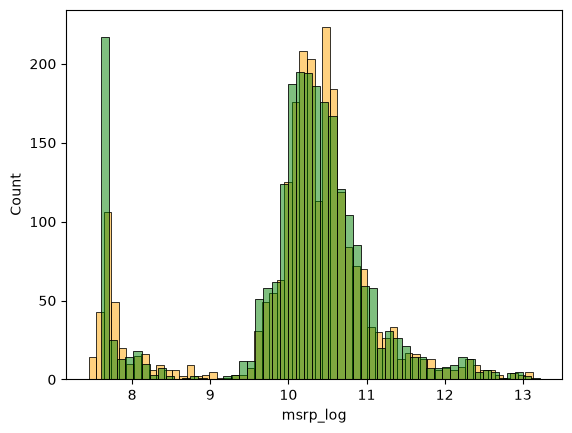

In [27]:
# validation
x_val = pd.get_dummies(x_val, columns=['model', 'make'], drop_first=True, dtype=int)

x_val["market_category"].fillna("unknown")
market_dummies = x_val["market_category"].str.get_dummies(sep=',', dtype=int).add_prefix('market_category_')

x_val.join(market_dummies)

x_val_v1 = x_val.reindex(columns=features, fill_value=0).fillna(0)
y_val_pred = predict(b, W, x_val_v1.values)
sns.histplot(y_val_pred, label='predicted', color='orange', alpha=0.5)
sns.histplot(y_val, label='actual', color='green', alpha=0.5)

In [28]:
rmse = np.sqrt(np.mean((y_val_pred - y_val) ** 2))
print(f"Validation RMSE: {rmse:.4f}")


Validation RMSE: 0.2182


<Axes: xlabel='msrp_log', ylabel='Count'>

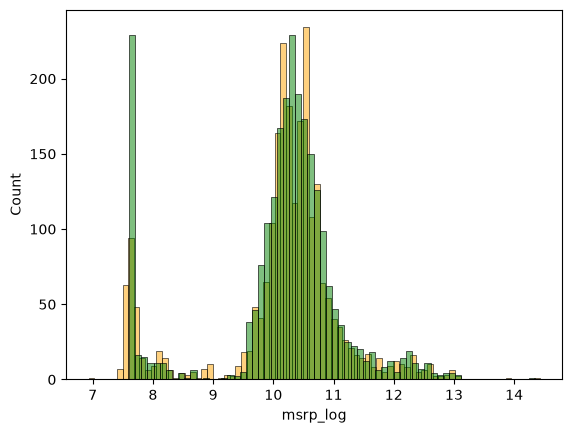

In [29]:
# join train and validation for final training
x_train_full = pd.concat([x_train_v5, x_val_v1], ignore_index=True)
y_train_full = pd.concat([y_train, y_val], ignore_index=True)

#
x_test = pd.get_dummies(x_test, columns=['model', 'make'], drop_first=True, dtype=int)
x_test["market_category"] = x_test["market_category"].fillna("unknown")
test_market_dummies = x_test["market_category"].str.get_dummies(sep=',', dtype=int).add_prefix('market_category_')
x_test = x_test.join(test_market_dummies)

x_train_full = x_train_full.reindex(columns=features, fill_value=0).fillna(0)
x_test = x_test.reindex(columns=features, fill_value=0)
b, W = train(x_train_full.values, y_train_full.values)
y_test_pred = predict(b, W, x_test.values)
sns.histplot(y_test_pred, label='predicted', color='orange', alpha=0.5)
sns.histplot(y_test, label='actual', color='green', alpha=0.5)

In [30]:
rmse = np.sqrt(np.mean((y_test_pred - y_test) ** 2))
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 0.2353


Bonus: Try a more powerful model like Random Forest and see if you can improve your RMSE. You can use the same features and data splits as before, just swap out the linear regression for a Random Forest Regressor from scikit-learn.

🌲 Random Forest Test RMSE: 0.1294


<Axes: xlabel='msrp_log', ylabel='Count'>

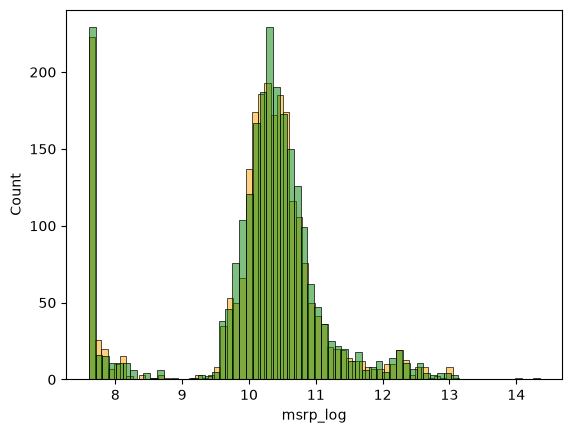

In [31]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize a fast, parallelized Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train on your clean, combined full matrix
rf_model.fit(x_train_full.values, y_train_full.values.flatten())

# 3. Predict on your aligned test matrix
y_test_pred = rf_model.predict(x_test.values)

# 4. Calculate your new RMSE
test_rmse = np.sqrt(np.mean((y_test_pred - y_test.values.flatten()) ** 2))
print(f"🌲 Random Forest Test RMSE: {test_rmse:.4f}")

sns.histplot(y_test_pred, label='predicted', color='orange', alpha=0.5)
sns.histplot(y_test, label='actual', color='green', alpha=0.5)

What I've learned:
- Clean your data before analysis. Standardize column names, handle missing values, and ensure data types are correct.
- Understand your data before modeling. Explore distributions, correlations, and data quality issues.
- Use a simple baseline model first. Start with linear regression to establish a performance benchmark before trying more complex models.
- Make sure you understand matrix operations and how to implement linear regression from scratch. This will give you a deeper understanding of how the model works and how to debug it.
- Feature engineering matters. Adding relevant features can significantly improve model performance.
- Do not try to use all features at once. Add features incrementally and evaluate their impact on performance.
- Validate your model on unseen data. Use a validation set to tune your model and a separate test set to evaluate final performance.